# Sample Specific Trimming Classification

        ## Manuscript targets
        - `Results / Sample-specific trimming classification`

        ## Primary inputs
        - `share/results/technical/trimming_classification.tsv`
- `share/results/biological/classification_summary.tsv`
- `share/results/technical/trimmomatic_detail.tsv`

        ## Rebuild scripts
        - `share/scripts/analysis/07_classify_sample_specific_trimming.py`
- `share/scripts/analysis/09_generate_analysis_reports.py`

        This notebook prefers the full local `data/` working set when it exists and falls back to the tiny `share/data/` example bundle otherwise.


## Inputs, methodology, and rebuild policy

The sample-specific classification table stores the preferred trimming decision and per-method helpful/neutral/harmful calls for each SRR. This notebook reproduces the headline counts in the manuscript and inspects the small outlier subset where trimming was preferred.


In [1]:
from __future__ import annotations

import math
import re
import subprocess
import textwrap
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    import seaborn as sns
    # --- Standardized Plotting Configuration ---
    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans", "Liberation Sans", "sans-serif"],
        "font.size": 8,
        "axes.titlesize": 10,
        "axes.labelsize": 9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "figure.titlesize": 11,
        "figure.dpi": 300,
        "savefig.dpi": 300,
        "savefig.bbox": "tight"
    })
    sns.set_theme(style="whitegrid", palette="colorblind")
    plt.rcParams.update({"font.family": "sans-serif"})
    # -------------------------------------------
except ImportError:
    sns = None

try:
    from IPython.display import display
except ImportError:
    display = print

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 220)
SRR_PATTERN = re.compile(r"(SRR\d+)")


def find_repo_root() -> Path:
    start = Path.cwd()
    for candidate in [start, *start.parents]:
        if (candidate / "share").exists() and (candidate / "share" / "results").exists():
            return candidate
    raise FileNotFoundError("Could not locate repo root from the notebook working directory.")


REPO_ROOT = find_repo_root()
SHARE = REPO_ROOT / "share"
RESULTS = SHARE / "results"
TECH = RESULTS / "technical"
BIO = RESULTS / "biological"
SUPP = RESULTS / "supplementary"
SHARE_DATA = SHARE / "data"
LOCAL_DATA = REPO_ROOT / "data"
SCRIPTS = SHARE / "scripts"
NOTEBOOK_DB = SHARE / "notebooks" / "srr_queue.db"


def data_dir(name: str) -> Path:
    local = LOCAL_DATA / name
    if local.exists():
        return local
    return SHARE_DATA / name


def load_table(path: Path) -> pd.DataFrame:
    sep = "," if path.suffix == ".csv" else "\t"
    return pd.read_csv(path, sep=sep)


def run_script(script_rel: str, *args: str) -> None:
    script = REPO_ROOT / script_rel
    if not script.exists():
        raise FileNotFoundError(script)
    cmd = ["python3", str(script), *map(str, args)] if script.suffix == ".py" else ["bash", str(script), *map(str, args)]
    print("$", " ".join(cmd))
    subprocess.run(cmd, check=True, cwd=REPO_ROOT)


def parse_fastqc_terminal_quality(fastqc_data_path: Path) -> float | None:
    rows: list[list[str]] = []
    in_section = False
    for line in fastqc_data_path.read_text(encoding="utf-8", errors="replace").splitlines():
        if line.startswith(">>Per base sequence quality"):
            in_section = True
            continue
        if in_section and line.startswith(">>END_MODULE"):
            break
        if in_section and line and not line.startswith("#"):
            rows.append(line.split("\t"))
    if not rows:
        return None
    means = []
    for row in rows:
        try:
            means.append(float(row[1]))
        except (IndexError, ValueError):
            continue
    if not means:
        return None
    return float(np.mean(means[-min(10, len(means)) :]))


def load_terminal_quality_table() -> pd.DataFrame:
    quality = load_table(TECH / "per_srr_quality.tsv")
    raw_dir = data_dir("flattened_fastqc_raw")
    rows = []
    if raw_dir.exists():
        for fastqc_data in raw_dir.glob("*/*_fastqc/fastqc_data.txt"):
            terminal_q = parse_fastqc_terminal_quality(fastqc_data)
            if terminal_q is None:
                continue
            project_id = fastqc_data.parents[1].name
            srr = fastqc_data.parent.name.removesuffix("_fastqc")
            if srr.endswith("_1") or srr.endswith("_2"):
                srr = srr[:-2]
            rows.append({
                "project_id": project_id,
                "SRR_ID": srr,
                "terminal_q_mean": terminal_q,
            })
    if rows:
        terminal = (
            pd.DataFrame(rows)
            .groupby(["project_id", "SRR_ID"], as_index=False)["terminal_q_mean"]
            .mean()
        )
        merged = quality.merge(terminal, on=["project_id", "SRR_ID"], how="left")
        merged["terminal_q_mean"] = merged["terminal_q_mean"].fillna(
            merged["Q_mean"] - merged["tail_quality_decay"]
        )
        return merged

    quality["terminal_q_mean"] = quality["Q_mean"] - quality["tail_quality_decay"]
    return quality


def srr_ids_from_tree(root: Path) -> set[str]:
    srrs: set[str] = set()
    if not root.exists():
        return srrs
    for path in root.rglob("*"):
        match = SRR_PATTERN.search(path.name) or SRR_PATTERN.search(path.as_posix())
        if match:
            srrs.add(match.group(1))
    return srrs


def flattened_dir_srr_sets(root: Path, cohort_projects: set[str] | None = None) -> dict[str, set[str]]:
    dir_sets: dict[str, set[str]] = {}
    if not root.exists():
        return dir_sets

    for flattened_dir in sorted(
        p for p in root.iterdir() if p.is_dir() and p.name.startswith("flattened_")
    ):
        dir_srrs: set[str] = set()
        for project_dir in sorted(p for p in flattened_dir.iterdir() if p.is_dir()):
            if cohort_projects is not None and project_dir.name not in cohort_projects:
                continue
            dir_srrs.update(srr_ids_from_tree(project_dir))
        dir_sets[flattened_dir.name] = dir_srrs
    return dir_sets


def collect_flattened_dir_audit(root: Path, cohort_projects: set[str] | None = None) -> pd.DataFrame:
    rows = []
    if not root.exists():
        return pd.DataFrame(
            columns=[
                "flattened_dir",
                "projects_total",
                "unique_srrs_total",
                "projects_in_cohort",
                "unique_srrs_in_cohort",
                "projects_outside_cohort",
                "unique_srrs_outside_cohort",
                "outside_cohort_projects",
            ]
        )

    for flattened_dir in sorted(
        p for p in root.iterdir() if p.is_dir() and p.name.startswith("flattened_")
    ):
        project_srrs: dict[str, set[str]] = {}
        for project_dir in sorted(p for p in flattened_dir.iterdir() if p.is_dir()):
            project_srrs[project_dir.name] = srr_ids_from_tree(project_dir)

        all_srrs = set().union(*project_srrs.values()) if project_srrs else set()
        if cohort_projects is None:
            in_cohort = project_srrs
            out_cohort: dict[str, set[str]] = {}
        else:
            in_cohort = {k: v for k, v in project_srrs.items() if k in cohort_projects}
            out_cohort = {k: v for k, v in project_srrs.items() if k not in cohort_projects}

        in_srrs = set().union(*in_cohort.values()) if in_cohort else set()
        out_srrs = set().union(*out_cohort.values()) if out_cohort else set()

        rows.append(
            {
                "flattened_dir": flattened_dir.name,
                "projects_total": len(project_srrs),
                "unique_srrs_total": len(all_srrs),
                "projects_in_cohort": len(in_cohort),
                "unique_srrs_in_cohort": len(in_srrs),
                "projects_outside_cohort": len(out_cohort),
                "unique_srrs_outside_cohort": len(out_srrs),
                "outside_cohort_projects": ", ".join(sorted(out_cohort)) if out_cohort else "",
            }
        )

    return pd.DataFrame(rows)


In [2]:
cls = load_table(TECH / "trimming_classification.tsv")
class_summary = load_table(BIO / "classification_summary.tsv")
trim = load_table(TECH / "trimmomatic_detail.tsv")
trim["surviving_pct"] = pd.to_numeric(trim["surviving_pct"], errors="coerce")
cls.head()


,SRR_ID,project_id,t_star,t_star_gene,t_star_path,U_class_gene,U_class_path,U_class,U_delta_path,U_read_loss,U_gene_loss,U_assigned_frac_loss,A_class_gene,A_class_path,A_class,A_delta_path,A_read_loss,A_gene_loss,A_assigned_frac_loss,P5_class_gene,P5_class_path,P5_class,P5_delta_path,P5_read_loss,P5_gene_loss,P5_assigned_frac_loss,P10_class_gene,P10_class_path,P10_class,P10_delta_path,P10_read_loss,P10_gene_loss,P10_assigned_frac_loss,P20_class_gene,P20_class_path,P20_class,P20_delta_path,P20_read_loss,P20_gene_loss,P20_assigned_frac_loss,P35_class_gene,P35_class_path,P35_class,P35_delta_path,P35_read_loss,P35_gene_loss,P35_assigned_frac_loss
0,SRR26033653,PRJNA1014965,U,U,P20,neutral,neutral,neutral,0.0,NaN,NaN,NaN,neutral,neutral,neutral,-0.000360,NaN,NaN,NaN,neutral,harmful,neutral,-0.000066,NaN,NaN,NaN,neutral,neutral,neutral,0.000000,NaN,NaN,NaN,neutral,helpful,neutral,0.000753,NaN,NaN,NaN,harmful,harmful,harmful,-0.339641,NaN,NaN,NaN
1,SRR26033654,PRJNA1014965,U,U,P5,neutral,neutral,neutral,0.0,NaN,NaN,NaN,neutral,helpful,neutral,-0.000231,NaN,NaN,NaN,neutral,helpful,neutral,-0.000362,NaN,NaN,NaN,neutral,helpful,neutral,-0.000141,NaN,NaN,NaN,neutral,neutral,neutral,-0.003765,NaN,NaN,NaN,harmful,harmful,harmful,-0.303843,NaN,NaN,NaN
2,SRR26033655,PRJNA1014965,U,U,P5,neutral,neutral,neutral,0.0,NaN,NaN,NaN,neutral,neutral,neutral,0.000199,NaN,NaN,NaN,neutral,helpful,neutral,0.000133,NaN,NaN,NaN,neutral,harmful,neutral,-0.000130,NaN,NaN,NaN,neutral,harmful,neutral,-0.001698,NaN,NaN,NaN,harmful,harmful,harmful,-0.342865,NaN,NaN,NaN
3,SRR26033656,PRJNA1014965,U,U,P20,neutral,neutral,neutral,0.0,NaN,NaN,NaN,neutral,helpful,neutral,0.000093,NaN,NaN,NaN,neutral,helpful,neutral,0.000128,NaN,NaN,NaN,neutral,helpful,neutral,-0.000157,NaN,NaN,NaN,neutral,helpful,neutral,0.000319,NaN,NaN,NaN,harmful,harmful,harmful,-0.318232,NaN,NaN,NaN
4,SRR26033657,PRJNA1014965,U,U,P5,neutral,neutral,neutral,0.0,NaN,NaN,NaN,neutral,neutral,neutral,-0.000267,NaN,NaN,NaN,neutral,helpful,neutral,-0.000200,NaN,NaN,NaN,neutral,neutral,neutral,-0.000369,NaN,NaN,NaN,neutral,helpful,neutral,-0.001076,NaN,NaN,NaN,harmful,harmful,harmful,-0.347712,NaN,NaN,NaN


In [3]:
methods = ["A", "P5", "P10", "P20", "P35"]
call_rows = []
for method in methods:
    counts = cls[f"{method}_class"].value_counts()
    call_rows.append(
        {
            "method": method,
            "helpful": int(counts.get("helpful", 0)),
            "neutral": int(counts.get("neutral", 0)),
            "harmful": int(counts.get("harmful", 0)),
        }
    )
call_summary = pd.DataFrame(call_rows)

outliers = cls.loc[cls["t_star"].ne("U")].copy()
outlier_projects = outliers["project_id"].value_counts().rename_axis("project_id").reset_index(name="n_outliers")

mode_map = {"A": "adapter_only", "P5": "P5", "P10": "P10", "P20": "P20", "P35": "P35"}
trim_lookup = trim.set_index(["SRR_ID", "mode"])["surviving_pct"].to_dict()

def preferred_survival_pct(row):
    if row["t_star"] == "U":
        return 100.0
    mode = mode_map.get(row["t_star"])
    return trim_lookup.get((row["SRR_ID"], mode), np.nan)

outliers["preferred_surviving_pct"] = outliers.apply(preferred_survival_pct, axis=1)
outliers["preferred_read_loss_pct"] = 100.0 - outliers["preferred_surviving_pct"]
outliers["preferred_delta_path"] = outliers.apply(lambda row: row.get(f"{row['t_star']}_delta_path", np.nan), axis=1)

headline = pd.Series(
    {
        "total_samples": len(cls),
        "samples_preferring_untrimmed": int((cls["t_star"] == "U").sum()),
        "samples_preferring_trimmed": int((cls["t_star"] != "U").sum()),
        "median_outlier_pathway_delta": outliers["preferred_delta_path"].median(),
        "median_outlier_read_loss_pct": outliers["preferred_read_loss_pct"].median(),
    }
)

display(headline.to_frame("value"))
display(call_summary)
display(outlier_projects)
display(outliers[["project_id", "SRR_ID", "t_star", "preferred_delta_path", "preferred_read_loss_pct"]].sort_values(["project_id", "SRR_ID"]))


,value
total_samples,830.000000
samples_preferring_untrimmed,812.000000
samples_preferring_trimmed,18.000000
median_outlier_pathway_delta,0.022382
median_outlier_read_loss_pct,1.160000


,method,helpful,neutral,harmful
0,A,2,825,3
1,P5,4,822,4
2,P10,3,819,8
3,P20,13,771,46
4,P35,3,320,507


,project_id,n_outliers
0,PRJNA373978,6
1,PRJNA321087,3
2,PRJNA1176539,2
3,PRJNA1120369,1
4,PRJNA1175639,1
5,PRJNA321967,1
6,PRJNA378952,1
7,PRJNA419934,1
8,PRJNA509121,1
9,PRJNA786266,1


,project_id,SRR_ID,t_star,preferred_delta_path,preferred_read_loss_pct
92,PRJNA1120369,SRR29302587,P20,0.068820,0.02
209,PRJNA1175639,SRR31149364,P35,0.147369,100.00
214,PRJNA1176539,SRR35798665,P5,0.016422,NaN
227,PRJNA1176539,SRR35798681,P20,0.289580,67.04
275,PRJNA321087,SRR3646711,P20,0.016479,2.34
278,PRJNA321087,SRR3646715,P20,0.015883,0.83
281,PRJNA321087,SRR3646818,P10,0.021952,1.49
296,PRJNA321967,SRR3543518,P20,0.019825,0.78
310,PRJNA373978,SRR5247101,P20,0.035176,1.30
314,PRJNA373978,SRR5247105,P20,0.033978,1.15


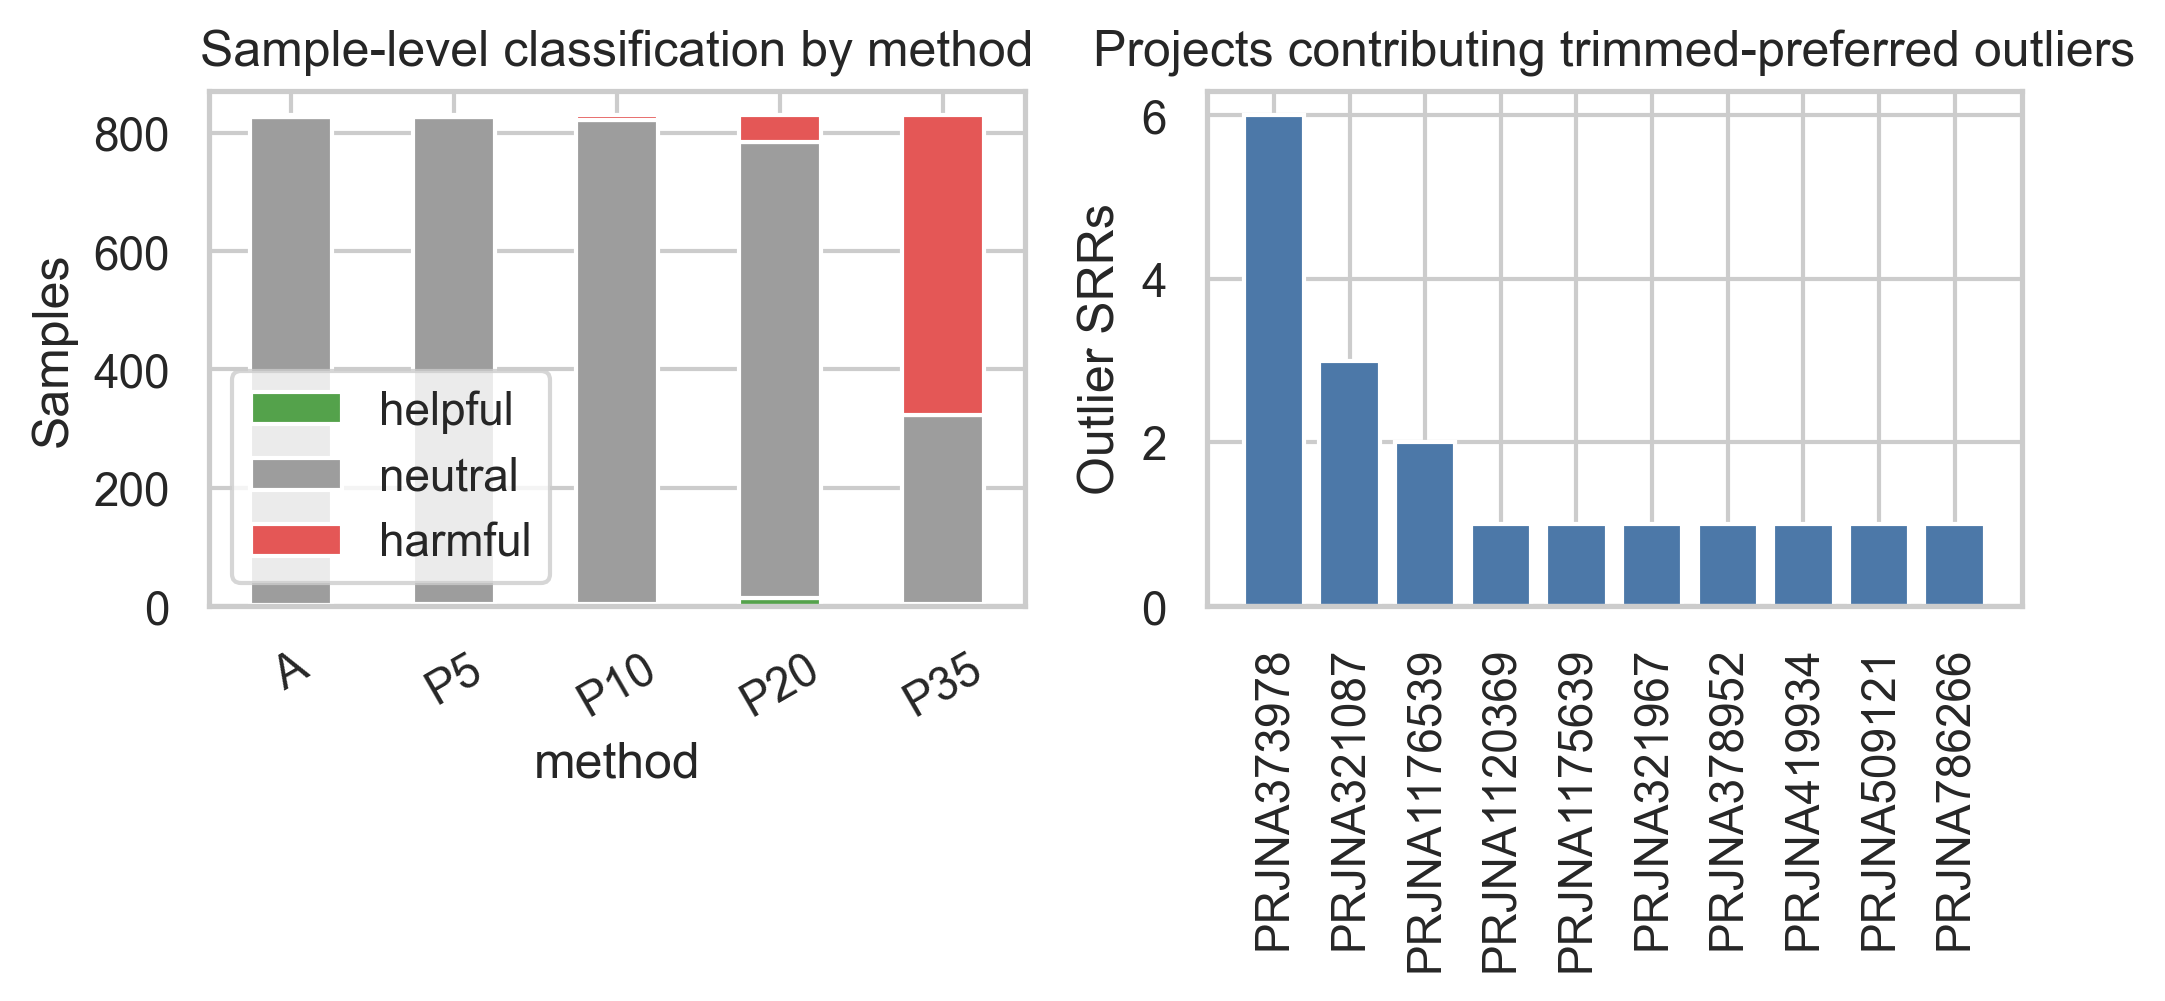

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(7.0, 3.5))

stacked = call_summary.set_index("method")[["helpful", "neutral", "harmful"]]
stacked.plot(kind="bar", stacked=True, ax=axes[0], color=["#54A24B", "#9D9D9D", "#E45756"])
axes[0].set_title("Sample-level classification by method")
axes[0].set_ylabel("Samples")
axes[0].tick_params(axis="x", rotation=30)

axes[1].bar(outlier_projects["project_id"], outlier_projects["n_outliers"], color="#4C78A8")
axes[1].set_title("Projects contributing trimmed-preferred outliers")
axes[1].set_ylabel("Outlier SRRs")
axes[1].tick_params(axis="x", rotation=90)

fig.tight_layout()
plt.show()
